In [1]:
from bs4 import BeautifulStoneSoup
import pandas as pd
import requests
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import re

In [2]:
# url='https://www.bloomberg.com/billionaires/'
# url='https://www.bloomberg.com/billionaires/'
url='https://beinsure.com/world-richest-people/'

In [3]:
import requests
from bs4 import BeautifulSoup


headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/114.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
print(response.status_code)  # should be 200 if allowed

soup = BeautifulSoup(response.text, "html.parser")
print(soup.title.text)


200
Richest People in the World 2026 ⭐ Top 50 Billionaires List (June)


In [4]:
row=soup.find_all('tr')
all=[]

for i in row:
    col=i.find_all('td')
    print(col)
    a=[i.text for i in col]
    print(a)
    all.append(a)

[<td><strong>№</strong></td>, <td><strong>NAME</strong></td>, <td><strong>WORTH</strong></td>, <td><strong>SOURCE</strong></td>]
['№', 'NAME', 'WORTH', 'SOURCE']
[<td>1</td>, <td><a href="https://beinsure.com/world-richest-people/#musk"><strong>Elon Musk</strong></a></td>, <td>$790B</td>, <td>Tesla, SpaceX</td>]
['1', 'Elon Musk', '$790B', 'Tesla, SpaceX']
[<td>2</td>, <td><strong><a href="https://beinsure.com/world-richest-people/#page">Larry Page</a></strong></td>, <td>$314B</td>, <td>Google</td>]
['2', 'Larry Page', '$314B', 'Google']
[<td>3</td>, <td><strong><a href="https://beinsure.com/world-richest-people/#brin">Sergey Brin</a></strong></td>, <td>$290B</td>, <td>Google</td>]
['3', 'Sergey Brin', '$290B', 'Google']
[<td>4</td>, <td><a href="https://beinsure.com/world-richest-people/#bezos"><strong>Jeff Bezos</strong></a></td>, <td>$275B</td>, <td>Amazon</td>]
['4', 'Jeff Bezos', '$275B', 'Amazon']
[<td>5</td>, <td><a href="https://beinsure.com/world-richest-people/#ellison"><stro

In [5]:
all

[['№', 'NAME', 'WORTH', 'SOURCE'],
 ['1', 'Elon Musk', '$790B', 'Tesla, SpaceX'],
 ['2', 'Larry Page', '$314B', 'Google'],
 ['3', 'Sergey Brin', '$290B', 'Google'],
 ['4', 'Jeff Bezos', '$275B', 'Amazon'],
 ['5', 'Larry Ellison', '$217B', 'Oracle'],
 ['6', 'Mark Zuckerberg', '$209B', 'Facebook'],
 ['7', 'Michael Dell', '$178B', 'Dell Tech'],
 ['8', 'Jensen Huang', '$172B', 'Nvidia'],
 ['9', 'Rob Walton', '$149B', 'Walmart'],
 ['10', 'Jim Walton', '$147B', 'Walmart'],
 ['11', 'Bernard Arnault', '$143B', 'LVMH'],
 ['12', 'Warren Buffett', '$140B', 'Berkshire Hathaway'],
 ['13', 'Alice Walton', '$137B', 'Walmart'],
 ['14', 'Amancio Ortega', '$134B', 'Zara'],
 ['15', 'Steve Ballmer', '$132B', 'Microsoft'],
 ['16', 'Carlos Slim Helu', '$123B', 'Telecom'],
 ['17', 'Changpeng Zhao', '$110B', 'Binance'],
 ['18', 'Michael Bloomberg', '$109B', 'Bloomberg LP'],
 ['19', 'Bill Gates', '$103B', 'Microsoft'],
 ['20', 'Mukesh Ambani', '$98B', 'Diversified'],
 ['21', 'Francoise Bettencourt Meyers', '$9

In [6]:
column=all.pop(0)

In [7]:
column

['№', 'NAME', 'WORTH', 'SOURCE']

In [8]:
all

[['1', 'Elon Musk', '$790B', 'Tesla, SpaceX'],
 ['2', 'Larry Page', '$314B', 'Google'],
 ['3', 'Sergey Brin', '$290B', 'Google'],
 ['4', 'Jeff Bezos', '$275B', 'Amazon'],
 ['5', 'Larry Ellison', '$217B', 'Oracle'],
 ['6', 'Mark Zuckerberg', '$209B', 'Facebook'],
 ['7', 'Michael Dell', '$178B', 'Dell Tech'],
 ['8', 'Jensen Huang', '$172B', 'Nvidia'],
 ['9', 'Rob Walton', '$149B', 'Walmart'],
 ['10', 'Jim Walton', '$147B', 'Walmart'],
 ['11', 'Bernard Arnault', '$143B', 'LVMH'],
 ['12', 'Warren Buffett', '$140B', 'Berkshire Hathaway'],
 ['13', 'Alice Walton', '$137B', 'Walmart'],
 ['14', 'Amancio Ortega', '$134B', 'Zara'],
 ['15', 'Steve Ballmer', '$132B', 'Microsoft'],
 ['16', 'Carlos Slim Helu', '$123B', 'Telecom'],
 ['17', 'Changpeng Zhao', '$110B', 'Binance'],
 ['18', 'Michael Bloomberg', '$109B', 'Bloomberg LP'],
 ['19', 'Bill Gates', '$103B', 'Microsoft'],
 ['20', 'Mukesh Ambani', '$98B', 'Diversified'],
 ['21', 'Francoise Bettencourt Meyers', '$93B', 'L’Oréal'],
 ['22', 'Thomas Pe

In [9]:
df=pd.DataFrame(all,columns=column)

In [10]:
df

,№,NAME,WORTH,SOURCE
0,1,Elon Musk,$790B,"Tesla, SpaceX"
1,2,Larry Page,$314B,Google
2,3,Sergey Brin,$290B,Google
3,4,Jeff Bezos,$275B,Amazon
4,5,Larry Ellison,$217B,Oracle
...,...,...,...,...
82,6,Mark Zuckerberg,$209B,Facebook
83,7,Michael Dell,$178B,Dell Tech
84,8,Jensen Huang,$172B,Nvidia
85,9,Rob Walton,$149B,Walmart


In [11]:
df

,№,NAME,WORTH,SOURCE
0,1,Elon Musk,$790B,"Tesla, SpaceX"
1,2,Larry Page,$314B,Google
2,3,Sergey Brin,$290B,Google
3,4,Jeff Bezos,$275B,Amazon
4,5,Larry Ellison,$217B,Oracle
...,...,...,...,...
82,6,Mark Zuckerberg,$209B,Facebook
83,7,Michael Dell,$178B,Dell Tech
84,8,Jensen Huang,$172B,Nvidia
85,9,Rob Walton,$149B,Walmart


In [12]:
df=df.to_csv('bloomberg2.csv')

In [13]:
df=pd.read_csv('bloomberg.csv')

In [14]:
df

,Unnamed: 0,№,NAME,WORTH,SOURCE
0,0,1,Elon Musk,$790B,"Tesla, SpaceX"
1,1,2,Larry Page,$314B,Google
2,2,3,Sergey Brin,$290B,Google
3,3,4,Jeff Bezos,$275B,Amazon
4,4,5,Larry Ellison,$217B,Oracle
...,...,...,...,...,...
82,82,6,Mark Zuckerberg,$209B,Facebook
83,83,7,Michael Dell,$178B,Dell Tech
84,84,8,Jensen Huang,$172B,Nvidia
85,85,9,Rob Walton,$149B,Walmart


In [15]:
df=df.iloc[:50]

In [16]:
df=df.iloc[:50]

In [17]:
df

,Unnamed: 0,№,NAME,WORTH,SOURCE
0,0,1,Elon Musk,$790B,"Tesla, SpaceX"
1,1,2,Larry Page,$314B,Google
2,2,3,Sergey Brin,$290B,Google
3,3,4,Jeff Bezos,$275B,Amazon
4,4,5,Larry Ellison,$217B,Oracle
5,5,6,Mark Zuckerberg,$209B,Facebook
6,6,7,Michael Dell,$178B,Dell Tech
7,7,8,Jensen Huang,$172B,Nvidia
8,8,9,Rob Walton,$149B,Walmart
9,9,10,Jim Walton,$147B,Walmart


In [18]:
df=pd.read_csv('bloomberg.csv')

In [19]:
df

,Unnamed: 0,№,NAME,WORTH,SOURCE
0,0,1,Elon Musk,$790B,"Tesla, SpaceX"
1,1,2,Larry Page,$314B,Google
2,2,3,Sergey Brin,$290B,Google
3,3,4,Jeff Bezos,$275B,Amazon
4,4,5,Larry Ellison,$217B,Oracle
...,...,...,...,...,...
82,82,6,Mark Zuckerberg,$209B,Facebook
83,83,7,Michael Dell,$178B,Dell Tech
84,84,8,Jensen Huang,$172B,Nvidia
85,85,9,Rob Walton,$149B,Walmart


In [20]:
df2=df.iloc[50:75]

In [21]:
df=df.iloc[:50]

In [22]:
df2=df2.drop(['SOURCE'],axis=1)

In [23]:
df=df.drop(['Unnamed: 0'],axis=1)

In [24]:
df.sample(5)

,№,NAME,WORTH,SOURCE
40,41,Jacqueline Mars,$47B,"Candy, Pet food"
27,28,Robin Zeng,$68B,Batteries
13,14,Amancio Ortega,$134B,Zara
5,6,Mark Zuckerberg,$209B,Facebook
4,5,Larry Ellison,$217B,Oracle


In [25]:
df2.sample(5)

,Unnamed: 0,№,NAME,WORTH
61,61,2014,"1,645",$6.4T
74,74,2001,538,$1.8T
68,68,2007,946,$3.5T
52,52,2023,"2,640",$12.2T
62,62,2013,"1,426",$5.4T


In [26]:
df.sample(5)

,№,NAME,WORTH,SOURCE
24,25,Gautam Adani,$78B,Infrastructure
22,23,Giancarlo Devasini,$89B,"Tether, Bitfinex"
42,43,Mark Mateschitz,$45B,Red Bull
46,47,Thomas Frist,$40B,Hospitals
5,6,Mark Zuckerberg,$209B,Facebook


In [27]:
df.shape

(50, 4)

In [28]:
df2.shape

(25, 4)

In [29]:
df.dtypes

№         object
NAME      object
WORTH     object
SOURCE    object
dtype: object

In [30]:
df['WORTH']=df['WORTH'].str.replace(r'[$B]','',regex=True)

In [31]:
df['WORTH']=df['WORTH'].astype('int')
df['NAME']=df['NAME'].astype('str')
df['SOURCE']=df['SOURCE'].astype('str')

In [32]:
df.dtypes

№         object
NAME      object
WORTH      int64
SOURCE    object
dtype: object

In [33]:
df.groupby('SOURCE')['WORTH'].sum()

SOURCE
Amazon                  275
Batteries                68
Berkshire Hathaway      140
Beverages                67
Binance                 110
Bloomberg LP            109
Candy, Pet food          94
Chanel                   78
Dell Tech               178
Discount brokerage       93
Diversified             147
Facebook                209
Fashion                  64
Financial software       42
Google                  604
Hedge funds              50
Hospitals                40
Infrastructure          118
Koch Industries         155
LVMH                    143
L’Oréal                  93
Microsoft               235
Mining                   59
Mining, beverages        46
Nutella                  48
Nvidia                  172
Online games             49
Oracle                  217
Red Bull                 45
Retail                   60
Shipping                 84
Telecom                 123
Telecom, Investments     66
Tesla, SpaceX           790
Tether, Bitfinex         89
TikTok       

<Axes: xlabel='SOURCE'>

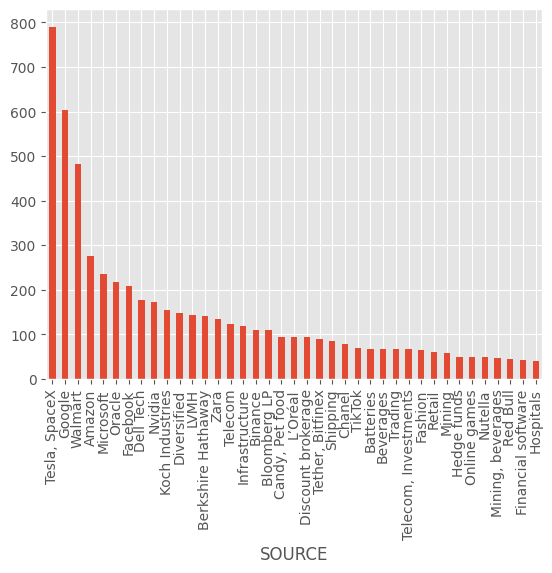

In [34]:
df.groupby('SOURCE')['WORTH'].sum().sort_values(ascending=0).plot(kind='bar')

<Axes: >

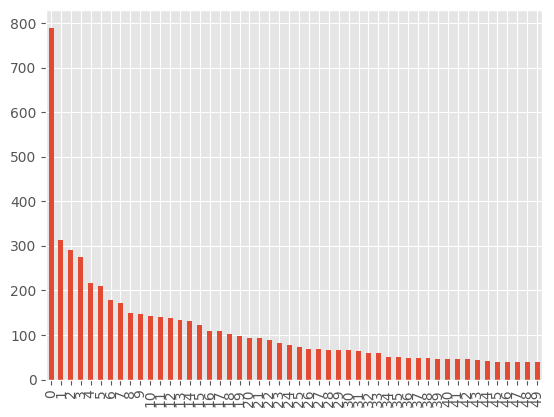

In [35]:
df['WORTH'].plot(kind='bar')

### Find outlier 

In [36]:
df.describe()

,WORTH
count,50.000000
mean,114.260000
std,118.534041
min,39.000000
25%,49.000000
50%,76.000000
75%,136.250000
max,790.000000


In [37]:
q2=df['WORTH'].mean()

In [38]:
q2

np.float64(114.26)

In [39]:
q1=df.WORTH.quantile(0.25)

In [40]:
q3=df.WORTH.quantile(0.75)

In [41]:
iqr=q3-q1

In [42]:
Lower_limit=q1-(1.5*iqr)
higher_limit=q3+(1.5*iqr)

In [43]:
Lower_limit

np.float64(-81.875)

In [44]:
higher_limit

np.float64(267.125)

#### Elon musk, larry page,sergey brin , jeff bezos are outlier 

<Axes: ylabel='Frequency'>

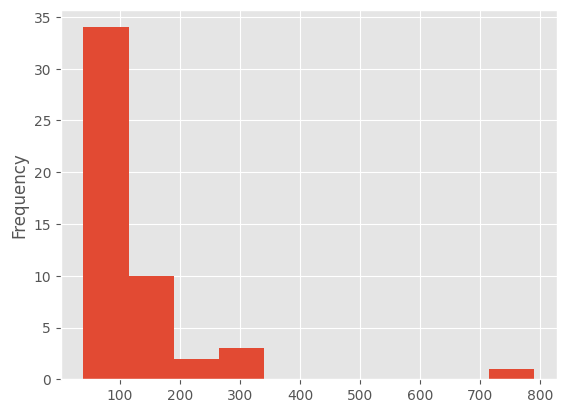

In [45]:
df['WORTH'].plot(kind='hist')

<Axes: >

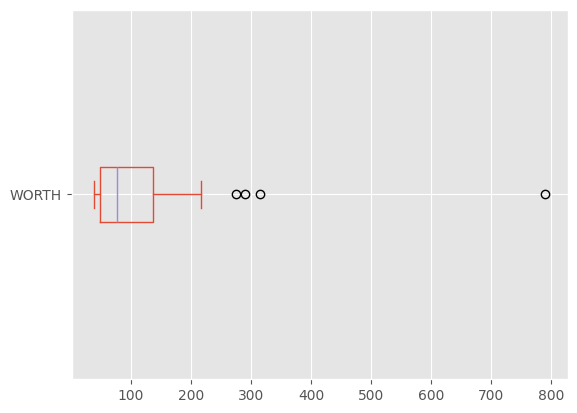

In [46]:
df.plot.box(vert=False)

<Axes: >

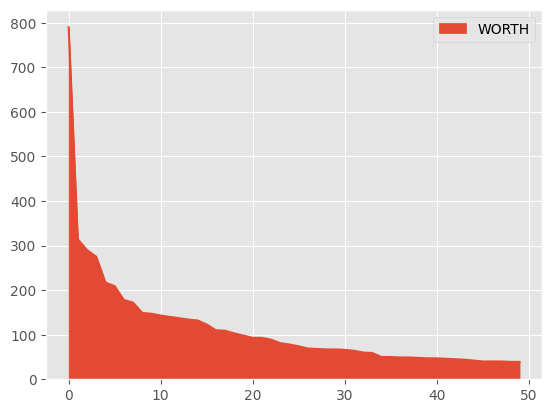

In [47]:
df.plot.area()